In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df = pd.concat([pd.read_csv("../data/train_dataset.csv"), pd.read_csv("../data/val_dataset.csv")])
test_df = pd.read_csv("../data/test_dataset.csv")

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

X_train_text = train_df["text"]
y_train = train_df["sentiment"]
X_test_text = test_df["text"]
y_test = test_df["sentiment"]

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train_text)
X_val = vectorizer.transform(X_test_text)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=["negative", "neutral", "positive"]))

Accuracy: 0.6918

              precision    recall  f1-score   support

    negative       0.72      0.74      0.73      4050
     neutral       0.58      0.68      0.63      3451
    positive       0.77      0.66      0.71      4499

    accuracy                           0.69     12000
   macro avg       0.69      0.69      0.69     12000
weighted avg       0.70      0.69      0.69     12000




--- super_short (4000 samples) ---
  Accuracy:  0.667
  F1 (macro): 0.661
  F1 per class: neg=0.695  neu=0.584  pos=0.704

--- short (4001 samples) ---
  Accuracy:  0.711
  F1 (macro): 0.711
  F1 per class: neg=0.731  neu=0.656  pos=0.747

--- medium (2000 samples) ---
  Accuracy:  0.728
  F1 (macro): 0.723
  F1 per class: neg=0.766  neu=0.655  pos=0.748

--- long (1999 samples) ---
  Accuracy:  0.666
  F1 (macro): 0.664
  F1 per class: neg=0.735  neu=0.627  pos=0.631


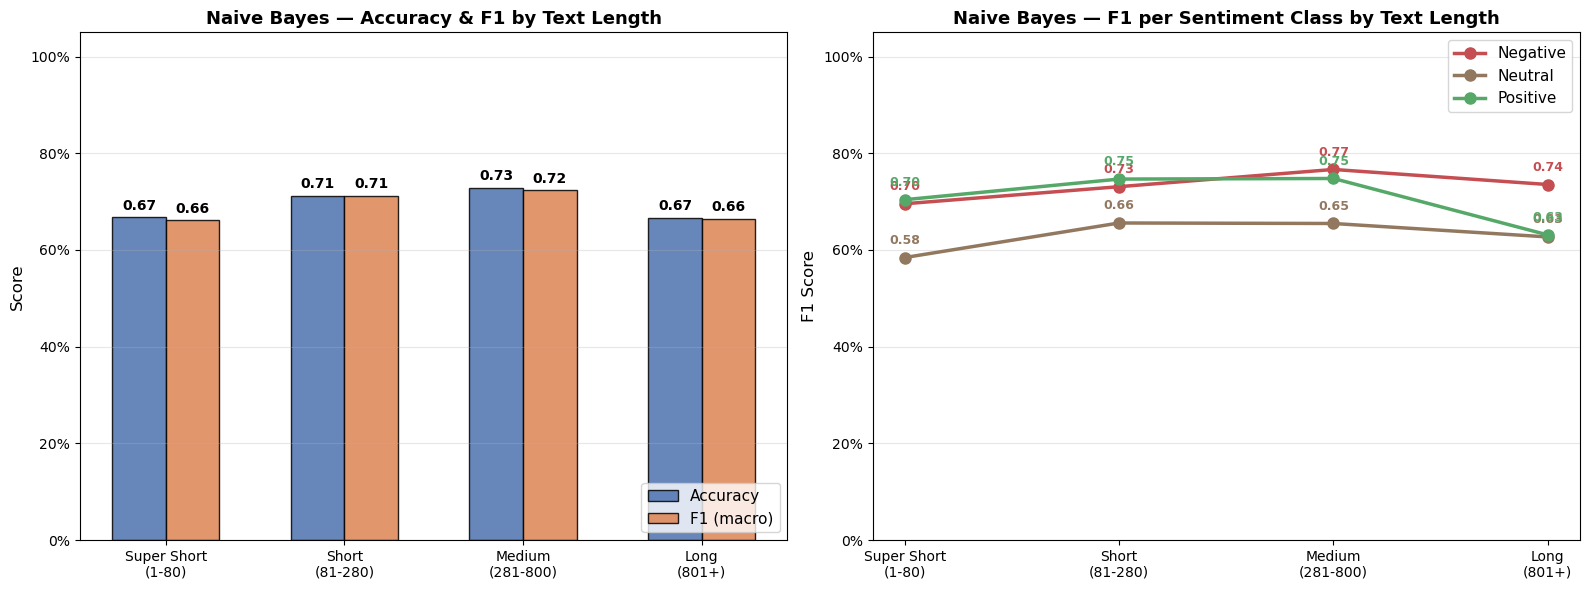

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.ticker as mticker

bucket_names = ["super_short", "short", "medium", "long"]
bucket_labels = ["Super Short\n(1-80)", "Short\n(81-280)", "Medium\n(281-800)", "Long\n(801+)"]

accuracies = []
f1_macros = []
f1_per_class = {"negative": [], "neutral": [], "positive": []}

for bucket in bucket_names:
    mask = test_df["bucket"] == bucket
    y_true_b = y_test[mask]
    y_pred_b = y_pred[mask]

    acc = accuracy_score(y_true_b, y_pred_b)
    f1_mac = f1_score(y_true_b, y_pred_b, average="macro", zero_division=0)
    accuracies.append(acc)
    f1_macros.append(f1_mac)

    for cls in ["negative", "neutral", "positive"]:
        f1_cls = f1_score(y_true_b, y_pred_b, average=None,
                          labels=["negative", "neutral", "positive"], zero_division=0)
        f1_per_class[cls].append(f1_cls[["negative", "neutral", "positive"].index(cls)])

    print(f"\n--- {bucket} ({mask.sum()} samples) ---")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  F1 (macro): {f1_mac:.3f}")
    print(f"  F1 per class: neg={f1_per_class['negative'][-1]:.3f}  "
          f"neu={f1_per_class['neutral'][-1]:.3f}  "
          f"pos={f1_per_class['positive'][-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(bucket_names))
width = 0.3

bars1 = ax1.bar(x - width/2, accuracies, width, label="Accuracy",
                color="#4C72B0", edgecolor="black", alpha=0.85)
bars2 = ax1.bar(x + width/2, f1_macros, width, label="F1 (macro)",
                color="#DD8452", edgecolor="black", alpha=0.85)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(bucket_labels, fontsize=10)
ax1.set_ylabel("Score", fontsize=12)
ax1.set_title("Naive Bayes: Accuracy & F1 by Text Length", fontsize=13, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend(fontsize=11, loc="lower right")
ax1.grid(axis="y", alpha=0.3)

colors = {"negative": "#C44E52", "neutral": "#937860", "positive": "#55A868"}
for cls, color in colors.items():
    ax2.plot(x, f1_per_class[cls], marker="o", markersize=8, linewidth=2.5,
             label=cls.capitalize(), color=color)
    for i, val in enumerate(f1_per_class[cls]):
        ax2.annotate(f"{val:.2f}", (x[i], val), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9, fontweight="bold", color=color)

ax2.set_xticks(x)
ax2.set_xticklabels(bucket_labels, fontsize=10)
ax2.set_ylabel("F1 Score", fontsize=12)
ax2.set_title("Naive Bayes: F1 per Sentiment Class by Text Length", fontsize=13, fontweight="bold")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=11)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()